## Test preprocessing

Ce notebook teste l'intégrité des données générée par le processus de preprocess

In [1]:
#
# assure le reload de src si modifications sont faite
#
%load_ext autoreload
%autoreload 2

In [2]:
#
# import utilitaires
#
%matplotlib inline

import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from pathlib import Path

In [3]:
#
# import package develope pour le projet
#
import ffury
from ffury.configs import (
    DatasetType,
    DEFAULT_CONFIG_FILE,
    load_config
)
from ffury.dataset import IndexedDataset

def get_config():
    # creation config - on sait que DEFAULT_CONFIG_FILE est dans le repertoire parent
    config = Path(ffury.__file__).parents[2].joinpath(DEFAULT_CONFIG_FILE)
    return load_config(config)

config = get_config()

In [4]:
# load datasets
dataset_train = IndexedDataset(config, DatasetType.TRAIN)
dataset_test = IndexedDataset(config, DatasetType.TEST)
dataset_validation = IndexedDataset(config, DatasetType.VALIDATION)

In [5]:
# validation quantite de labels
assert len(dataset_train.species_label) == 5
assert len(dataset_test.species_label) == 5
assert len(dataset_validation.species_label) == 5

In [6]:
# inspection visuelle
print(dataset_train.species_label)
print(len(dataset_train.species_label))

['Barn Swallow', 'Common Buzzard', 'Western Yellow Wagtail', 'Thrush Nightingale', 'Willow Warbler']
5


In [7]:
groupe_length, segment_length_, hop_length = config.preprocess.group_frame_infos()
print(groupe_length, segment_length_, hop_length)

60 30 15


In [8]:
# train
print(dataset_train.melspectrogram_groups.shape)
print(dataset_train.y.shape)
print(dataset_train.y.head())

num_samples, group_segment_count, n_mels, segment_length = dataset_train.melspectrogram_groups.shape
assert num_samples == config.preprocess.group_count * 5 * config.preprocess.split_train_size
assert group_segment_count == config.preprocess.group_segment_count
assert n_mels == config.preprocess.spectrogram_n_mels
assert segment_length == segment_length_

assert dataset_train.lat_long.shape == (num_samples, 2)

np.unique( dataset_train.y )

(4116, 3, 128, 30)
(4116, 1)
   specie
0       4
1       3
2       2
3       3
4       0


array([0, 1, 2, 3, 4], dtype=int32)

In [9]:
# test
print(dataset_test.melspectrogram_groups.shape)
print(dataset_test.y.shape)
print(dataset_test.y.head())

num_samples, group_segment_count, n_mels, segment_length = dataset_test.melspectrogram_groups.shape
assert num_samples == config.preprocess.group_count * 5 * config.preprocess.split_test_size
assert group_segment_count == config.preprocess.group_segment_count
assert n_mels == config.preprocess.spectrogram_n_mels
assert segment_length == segment_length_

assert dataset_test.lat_long.shape == (num_samples, 2)

np.unique( dataset_test.y )

(1372, 3, 128, 30)
(1372, 1)
   specie
0       2
1       3
2       3
3       1
4       0


array([0, 1, 2, 3, 4], dtype=int32)

In [10]:
# validation
print(dataset_validation.melspectrogram_groups.shape)
print(dataset_validation.y.shape)
print(dataset_validation.y.head())

num_samples, group_segment_count, n_mels, segment_length = dataset_validation.melspectrogram_groups.shape
assert num_samples == config.preprocess.group_count * 5 * (1 - config.preprocess.split_train_size - config.preprocess.split_test_size)
assert group_segment_count == config.preprocess.group_segment_count
assert n_mels == config.preprocess.spectrogram_n_mels
assert segment_length == segment_length_

assert dataset_validation.lat_long.shape == (num_samples, 2)

np.unique( dataset_validation.y )

(1372, 3, 128, 30)
(1372, 1)
   specie
0       3
1       1
2       0
3       1
4       3


array([0, 1, 2, 3, 4], dtype=int32)

(128, 30) 22050


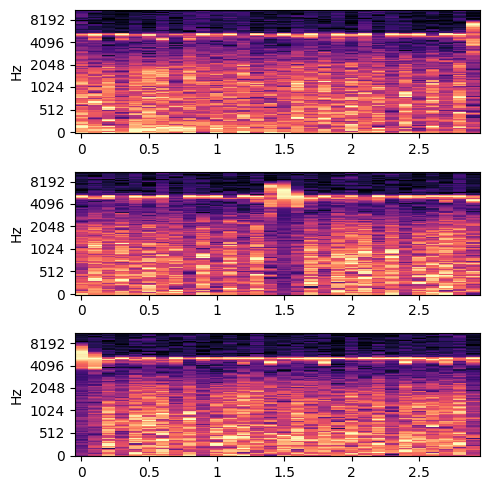

In [11]:
import librosa as rosa
from h5py import Dataset

assert dataset_validation.melspectrogram_groups.is_virtual

print(dataset_validation.melspectrogram_groups[0, 0].shape, config.preprocess.clip_sampling_rate_hz)

def plot(data):
    plt.subplot(311)
    rosa.display.specshow(data[0],
                          x_axis='time',
                          y_axis='mel',
                          sr=config.preprocess.clip_sampling_rate_hz,
                          ax=plt.gca(),
                          n_fft=config.preprocess.spectrogram_n_ftt,
                          hop_length=config.preprocess.spectrogram_hop_length)
    plt.xlabel("")

    plt.subplot(312)
    rosa.display.specshow(data[1],
                          x_axis='time',
                          y_axis='mel',
                          sr=config.preprocess.clip_sampling_rate_hz,
                          ax=plt.gca(),
                          n_fft=config.preprocess.spectrogram_n_ftt,
                          hop_length=config.preprocess.spectrogram_hop_length)
    plt.xlabel("")

    plt.subplot(313)
    rosa.display.specshow(data[2],
                          x_axis='time',
                          y_axis='mel',
                          sr=config.preprocess.clip_sampling_rate_hz,
                          ax=plt.gca(),
                          n_fft=config.preprocess.spectrogram_n_ftt,
                          hop_length=config.preprocess.spectrogram_hop_length)
    plt.xlabel("")

    # assert not np.allclose(data[0], data[1])
    # assert not np.allclose(data[0], data[2])
    # assert not np.allclose(data[1], data[2])

fig = plt.figure(figsize=(5, 5))
plot( dataset_test.melspectrogram_groups[50] )
plt.tight_layout()
plt.show()

(60, 30, 15)
(6000, 3000, 1500)
(128, 60)


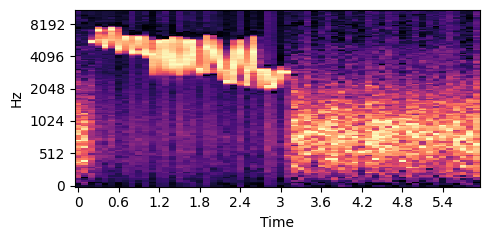

In [12]:
from ffury.dataset.hdf5 import open_file
from ffury.transforms.properties import _SPECTROGRAM

print( config.preprocess.group_frame_infos() )
print( config.preprocess.group_ms_infos() )

path = Path.joinpath(config.paths.BUILD_DIR, _SPECTROGRAM, "wlwwar/XC638950.hdf5")

with open_file(path, "r") as file:
    data = file[_SPECTROGRAM]

    print( data[:, 451:511].shape)

    fig = plt.figure(figsize=(5, 2.5))
    rosa.display.specshow(data[:, 451:511],
                          x_axis='time',
                          y_axis='mel',
                          sr=config.preprocess.clip_sampling_rate_hz,
                          ax=plt.gca(),
                          n_fft=config.preprocess.spectrogram_n_ftt,
                          hop_length=config.preprocess.spectrogram_hop_length)
    plt.tight_layout()
    plt.show()

In [13]:
# /Users/jfgagnon/Projects/FeatheredFury/data/melspectrogram/combuz1/XC335909.hdf5 melspectrogram
#     1369 0 (232, 262)
#     1369 1 (247, 277)
#     1369 2 (262, 292)
# /Users/jfgagnon/Projects/FeatheredFury/data/melspectrogram/combuz1/XC636833.hdf5 melspectrogram
#     1370 0 (12, 42)
#     1370 1 (27, 57)
#     1370 2 (42, 72)
# /Users/jfgagnon/Projects/FeatheredFury/data/melspectrogram/wlwwar/XC638950.hdf5 melspectrogram
#     766 0 (451, 481)
#     766 1 (466, 496)
#     766 2 (481, 511)